In [1]:
import pandas as pd

tekme = pd.read_csv('podatki/tekme.csv')
tekme.head()

,datum,domaca_ekipa,goli_domaca,goli_gost,gostujoca_ekipa,kartoni_domaci,kartoni_gostje,rdeci_domaci,rdeci_gostje,rumeni_domaci,rumeni_gostje,strelci_domaci,strelci_gostje
0,16 Aug 2025,Aston Villa,0,0,Newcastle United,"Boubacar Kamara 58' (Y), Ezri Konsa 66' (R)",Joelinton 45' (Y),1,0,1,1,NaN,NaN
1,17 Aug 2025,Chelsea,0,0,Crystal Palace,"Reece James 24' (Y), Estêvão 74' (Y)","Daniel Muñoz 28' (Y), Jean-Philippe Mateta 33'...",0,0,2,3,NaN,NaN
2,17 Aug 2025,Manchester United,0,1,Arsenal,Patrick Dorgu 85' (Y),"Riccardo Calafiori 42' (Y), David Raya 85' (Y)...",0,0,1,4,NaN,Riccardo Calafiori (Defender) 13'
3,16 Aug 2025,Brighton and Hove Albion,1,1,Fulham,"Kaoru Mitoma 60' (Y), Ferdi Kadioğlu 73' (Y), ...","Calvin Bassey 31' (Y), Tom Cairney 90+3' (Y), ...",0,0,3,3,NaN,Rodrigo Muniz (Forward) 90+6'
4,18 Aug 2025,Leeds United,1,0,Everton,NaN,"Tim Iroegbunam 56' (Y), Carlos Alcaraz 63' (Y)",0,0,0,2,NaN,NaN


In [2]:
len(tekme)

760

In [3]:
tekme.info()

<class 'pandas.DataFrame'>
RangeIndex: 760 entries, 0 to 759
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   datum            760 non-null    str  
 1   domaca_ekipa     760 non-null    str  
 2   goli_domaca      760 non-null    int64
 3   goli_gost        760 non-null    int64
 4   gostujoca_ekipa  760 non-null    str  
 5   kartoni_domaci   640 non-null    str  
 6   kartoni_gostje   673 non-null    str  
 7   rdeci_domaci     760 non-null    int64
 8   rdeci_gostje     760 non-null    int64
 9   rumeni_domaci    760 non-null    int64
 10  rumeni_gostje    760 non-null    int64
 11  strelci_domaci   552 non-null    str  
 12  strelci_gostje   537 non-null    str  
dtypes: int64(6), str(7)
memory usage: 77.3 KB


In [4]:
tekme.describe()

,goli_domaca,goli_gost,rdeci_domaci,rdeci_gostje,rumeni_domaci,rumeni_gostje
count,760.000000,760.000000,760.000000,760.000000,760.000000,760.000000
mean,1.519737,1.322368,0.063158,0.063158,1.832895,2.171053
std,1.224317,1.142092,0.259137,0.243407,1.343396,1.417825
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000
50%,1.000000,1.000000,0.000000,0.000000,2.000000,2.000000
75%,2.000000,2.000000,0.000000,0.000000,3.000000,3.000000
max,7.000000,6.000000,2.000000,1.000000,7.000000,8.000000


In [5]:
tekme.isna().sum()

datum                0
domaca_ekipa         0
goli_domaca          0
goli_gost            0
gostujoca_ekipa      0
kartoni_domaci     120
kartoni_gostje      87
rdeci_domaci         0
rdeci_gostje         0
rumeni_domaci        0
rumeni_gostje        0
strelci_domaci     208
strelci_gostje     223
dtype: int64

In [6]:
tekme['datum'] = pd.to_datetime(tekme['datum'], format='%d %b %Y')



### 1. Koliko tekem je bilo odigranih v vsaki sezoni


In [7]:
def doloci_sezono(datum):
    if datum.month >= 8:
        sezona = str(datum.year) + '/' + str(datum.year + 1)
    else:
        sezona = str(datum.year - 1) + '/' + str(datum.year)
    return sezona

tekme['sezona'] = tekme['datum'].apply(doloci_sezono)
tekme['sezona'].value_counts()

sezona
2025/2026    380
2024/2025    380
Name: count, dtype: int64

# 1. Analiza tekem glede na gole

### 2. Katera ekipa je dosegla največ golov skupaj?

#### 2.1 Goli - Domači

In [8]:
goli_doma = tekme.groupby('domaca_ekipa')['goli_domaca'].sum()
goli_doma = goli_doma.sort_values(ascending=False)
goli_doma

domaca_ekipa
Manchester City             88
Liverpool                   76
Arsenal                     76
Newcastle United            76
Brentford                   73
Aston Villa                 66
Manchester United           62
Chelsea                     61
Brighton and Hove Albion    60
Fulham                      57
Tottenham Hotspur           57
Everton                     52
AFC Bournemouth             52
West Ham United             50
Wolverhampton Wanderers     46
Nottingham Forest           46
Crystal Palace              43
Leeds United                29
Sunderland                  25
Burnley                     18
Leicester City              15
Ipswich Town                14
Southampton                 13
Name: goli_domaca, dtype: int64

In [10]:
skupni_goli_domacih = goli_doma.sum()
skupni_goli_domacih

np.int64(1155)

#### 2.2 Goli - Gostujoči

In [13]:
goli_gost = tekme.groupby('gostujoca_ekipa')['goli_gost'].sum()
goli_gost = goli_gost.sort_values(ascending=False)
goli_gost

gostujoca_ekipa
Liverpool                   73
Arsenal                     64
AFC Bournemouth             64
Manchester City             61
Chelsea                     61
Nottingham Forest           60
Brighton and Hove Albion    58
Tottenham Hotspur           55
Manchester United           51
Crystal Palace              49
Aston Villa                 48
Brentford                   48
Newcastle United            45
Fulham                      44
West Ham United             42
Everton                     37
Wolverhampton Wanderers     35
Ipswich Town                22
Burnley                     20
Leeds United                20
Leicester City              18
Sunderland                  17
Southampton                 13
Name: goli_gost, dtype: int64

#### 2.3 Goli - Skupno



In [17]:
goli_skupaj = goli_doma.add(goli_gost, fill_value=0)
goli_skupaj = goli_skupaj.sort_values(ascending=False)
goli_skupaj.index.name = 'ekipa'
goli_skupaj.head(10)

ekipa
Liverpool                   149
Manchester City             149
Arsenal                     140
Chelsea                     122
Newcastle United            121
Brentford                   121
Brighton and Hove Albion    118
AFC Bournemouth             116
Aston Villa                 114
Manchester United           113
dtype: int64

## 1.1. Ali ima domača ekipa prednost glede na število golov?

In [14]:
povp_doma = tekme.groupby('domaca_ekipa')['goli_domaca'].mean()
povp_doma = povp_doma.sort_values(ascending=False)
povp_doma = round(povp_doma, 2)
povp_doma

domaca_ekipa
Manchester City             2.32
Liverpool                   2.00
Arsenal                     2.00
Newcastle United            2.00
Brentford                   1.92
Aston Villa                 1.74
Manchester United           1.63
Chelsea                     1.61
Brighton and Hove Albion    1.58
Leeds United                1.53
Tottenham Hotspur           1.50
Fulham                      1.50
AFC Bournemouth             1.37
Everton                     1.37
West Ham United             1.32
Sunderland                  1.32
Wolverhampton Wanderers     1.21
Nottingham Forest           1.21
Crystal Palace              1.13
Burnley                     0.95
Leicester City              0.79
Ipswich Town                0.74
Southampton                 0.68
Name: goli_domaca, dtype: float64

In [15]:
povp_gost = tekme.groupby('gostujoca_ekipa')['goli_gost'].mean()
povp_gost = povp_gost.sort_values(ascending=False)
povp_gost = round(povp_gost, 2)
povp_gost

gostujoca_ekipa
Liverpool                   1.92
Arsenal                     1.68
AFC Bournemouth             1.68
Manchester City             1.61
Chelsea                     1.61
Nottingham Forest           1.58
Brighton and Hove Albion    1.53
Tottenham Hotspur           1.45
Manchester United           1.34
Crystal Palace              1.29
Aston Villa                 1.26
Brentford                   1.26
Newcastle United            1.18
Ipswich Town                1.16
Fulham                      1.16
West Ham United             1.11
Burnley                     1.05
Leeds United                1.05
Everton                     0.97
Leicester City              0.95
Wolverhampton Wanderers     0.92
Sunderland                  0.89
Southampton                 0.68
Name: goli_gost, dtype: float64

Zmaga domačih: 317 - 41.7 %
Zmaga gostov: 246 - 32.4 %
Neodločeno: 197 - 25.9 %


<Axes: >

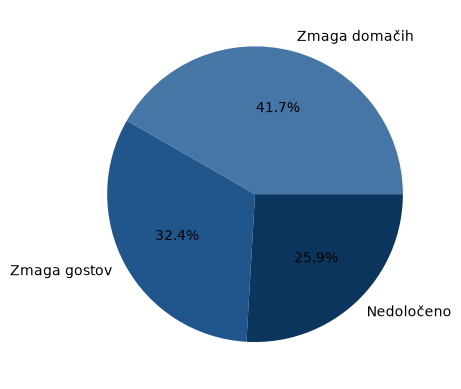

In [35]:
izidi = []

for i in range(len(tekme)):
    doma_goli = tekme['goli_domaca'][i]
    gost_goli = tekme['goli_gost'][i]

    if doma_goli > gost_goli:
        izid = 'Zmaga domačih'
    
    elif doma_goli < gost_goli:
        izid = 'Zmaga gostov'
    
    else:
        izid = 'Nedoločeno'
    
    izidi.append(izid)

tekme['izid'] = izidi

stevilo_domaci = 0
stevilo_gostje = 0
stevilo_nedolocen = 0

for izid in izidi:
    if izid == 'Zmaga domačih':
        stevilo_domaci += 1
    elif izid == 'Zmaga gostov':
        stevilo_gostje += 1
    else:
        stevilo_nedolocen += 1

skupaj = len(izidi)

print("Zmaga domačih:", stevilo_domaci, "-", round(stevilo_domaci / skupaj * 100, 1), "%")
print("Zmaga gostov:", stevilo_gostje, "-", round(stevilo_gostje / skupaj * 100, 1), "%")
print("Neodločeno:", stevilo_nedolocen, "-", round(stevilo_nedolocen / skupaj * 100, 1), "%")

tekme['izid'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['#4676a6', '#20568c', '#0c355e']
    
)

## 1.2. Delež vseh zadetkov glede na pozicijo igralca

<Axes: >

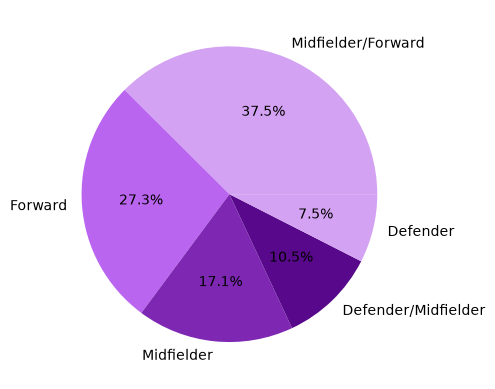

In [32]:
import re

vse_pozicije = []

for besedilo in tekme['strelci_domaci'].dropna():
    vse_pozicije += re.findall(r'\(([A-Za-z/ ]+)\)', besedilo)

for besedilo in tekme['strelci_gostje'].dropna():
    vse_pozicije += re.findall(r'\(([A-Za-z/ ]+)\)', besedilo)

len(vse_pozicije)

pozicije_stevilo = pd.Series(vse_pozicije).value_counts()
pozicije_delez = pd.Series(vse_pozicije).value_counts(normalize=True) * 100

povzetek_pozicij = pd.DataFrame({
    'stevilo_golov': pozicije_stevilo,
    'delez (%)': pozicije_delez.round(1)
})

povzetek_pozicij

pozicije_stevilo.plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['#d4a2f2', '#ba65f0', '#7d27b3', '#58088a']
     )

## 1.3. V katerem delu igre so najbolj pogosti goli?

0-15 min: 254
16-30 min: 254
31-45 min: 370
46-60 min: 304
61-75 min: 298
76-90+ min: 461


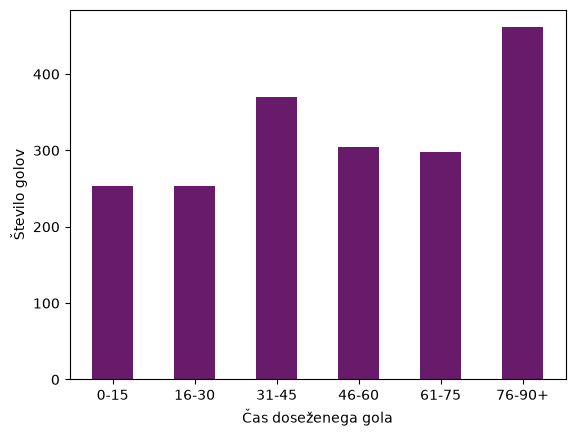

In [40]:
vse_minute = []

for besedilo in tekme['strelci_domaci']:
    if pd.isna(besedilo):
        continue
    najdene = re.findall(r"(\d{1,3})(?:\+\d{1,2})?'", besedilo)
    for m in najdene:
        vse_minute.append(int(m))

for besedilo in tekme['strelci_gostje']:
    if pd.isna(besedilo):
        continue
    najdene = re.findall(r"(\d{1,3})(?:\+\d{1,2})?'", besedilo)
    for m in najdene:
        vse_minute.append(int(m))

len(vse_minute)


stevilo_0_15 = 0
stevilo_16_30 = 0
stevilo_31_45 = 0
stevilo_46_60 = 0
stevilo_61_75 = 0
stevilo_76_90 = 0

for minuta in vse_minute:
    if minuta <= 15:
        stevilo_0_15 += 1
    elif minuta <= 30:
        stevilo_16_30 += 1
    elif minuta <= 45:
        stevilo_31_45 += 1
    elif minuta <= 60:
        stevilo_46_60 += 1
    elif minuta <= 75:
        stevilo_61_75 += 1
    else:
        stevilo_76_90 += 1

print("0-15 min:", stevilo_0_15)
print("16-30 min:", stevilo_16_30)
print("31-45 min:", stevilo_31_45)
print("46-60 min:", stevilo_46_60)
print("61-75 min:", stevilo_61_75)
print("76-90+ min:", stevilo_76_90)

import matplotlib.pyplot as plt

minute = ['0-15', '16-30', '31-45', '46-60', '61-75', '76-90+']
goli = [stevilo_0_15, stevilo_16_30, stevilo_31_45,
        stevilo_46_60, stevilo_61_75, stevilo_76_90]


plt.xlabel('Čas doseženega gola')
plt.ylabel('Število golov')
plt.bar( minute, goli, color='#681a6b', width=0.5 )
plt.show()

## 1.4. Lestvica strelcev


In [4]:
import pandas as pd
strelci = pd.read_csv('podatki/strelci.csv')
strelci.head()

lestvica = strelci.sort_values('goli', ascending=False)
lestvica

,ekipa,goli,ime
18,Liverpool,29,Mohamed Salah
0,Manchester City,27,Erling Haaland
19,Newcastle United,23,Alexander Isak
1,Brentford,22,Igor Thiago
20,Manchester City,22,Erling Haaland
21,Brentford,20,Bryan Mbeumo
22,Brentford,19,Yoane Wissa
2,Aston Villa,16,Ollie Watkins
23,Aston Villa,16,Ollie Watkins
24,Wolverhampton Wanderers,15,Matheus Cunha


# 3. Analiza tekem glede na rumene in rdeče kartone

## 1. Povprečno število rdečih in rumenih kartonov po ekipah

In [34]:
ekipe = []
imena_ekip = []
seznam_rumenih = []
seznam_rdecih = []

for ekipa in tekme['domaca_ekipa']:
    if ekipa not in ekipe:
        ekipe.append(ekipa)

for ekipa in tekme['gostujoca_ekipa']:
    if ekipa not in ekipe:
        ekipe.append(ekipa)

for ekipa in ekipe:
    rumeni_skupaj = 0
    rdeci_skupaj = 0
    stevilo_tekem = 0

    for i in range(len(tekme)):
        if tekme['domaca_ekipa'][i] == ekipa:
            rumeni_skupaj += tekme['rumeni_domaci'][i]
            rdeci_skupaj += tekme['rdeci_domaci'][i]
            stevilo_tekem += 1

        if tekme['gostujoca_ekipa'][i] == ekipa:
            rumeni_skupaj += tekme['rumeni_gostje'][i]
            rdeci_skupaj += tekme['rdeci_gostje'][i]
            stevilo_tekem += 1

    povp_rumeni = rumeni_skupaj / stevilo_tekem
    povp_rdeci = rdeci_skupaj / stevilo_tekem

    imena_ekip.append(ekipa)
    seznam_rumenih.append(round(povp_rumeni, 2))
    seznam_rdecih.append(round(povp_rdeci, 2))


tabela_kartonov = pd.DataFrame({
    'ekipa': imena_ekip,
    'povprecno_rumenih': seznam_rumenih,
    'povprecno_rdecih': seznam_rdecih
})

tabela_kartonov

,ekipa,povprecno_rumenih,povprecno_rdecih
0,Aston Villa,1.76,0.07
1,Chelsea,2.63,0.13
2,Manchester United,1.97,0.08
3,Brighton and Hove Albion,2.14,0.04
4,Leeds United,1.68,0.03
5,Sunderland,2.18,0.08
6,Tottenham Hotspur,2.28,0.07
7,Wolverhampton Wanderers,2.07,0.07
8,Nottingham Forest,1.96,0.04
9,AFC Bournemouth,2.43,0.07


### 1.1 Razmerje povprečnega števila rdečih in rumenih kartonov

In [35]:
razmerja = []

for i in range(len(tabela_kartonov)):
    rumeni = tabela_kartonov['povprecno_rumenih'][i]
    rdeci = tabela_kartonov['povprecno_rdecih'][i]
    
    razmerje = rdeci / rumeni
    razmerja.append(round(razmerje, 3))

tabela_kartonov['razmerje_rdeci_rumeni'] = razmerja
tabela_kartonov

,ekipa,povprecno_rumenih,povprecno_rdecih,razmerje_rdeci_rumeni
0,Aston Villa,1.76,0.07,0.040
1,Chelsea,2.63,0.13,0.049
2,Manchester United,1.97,0.08,0.041
3,Brighton and Hove Albion,2.14,0.04,0.019
4,Leeds United,1.68,0.03,0.018
5,Sunderland,2.18,0.08,0.037
6,Tottenham Hotspur,2.28,0.07,0.031
7,Wolverhampton Wanderers,2.07,0.07,0.034
8,Nottingham Forest,1.96,0.04,0.020
9,AFC Bournemouth,2.43,0.07,0.029


## 3.2. V katerem delu igre so najbolj pogosti rdeči/rumeni kartoni?

In [16]:
import re

rumene_minute = []
rdece_minute = []

for stolpec in ['kartoni_domaci', 'kartoni_gostje']:
    for besedilo in tekme[stolpec]:

        if pd.isna(besedilo):
            continue

        
        najdene = re.findall(r"(\d{1,3})(?:\+\d{1,2})?' \(([YR])\)", str(besedilo))

        for minuta, vrsta in najdene:

            minuta = int(minuta)

            if vrsta == "Y":
                rumene_minute.append(minuta)
            elif vrsta == "R":
                rdece_minute.append(minuta)



rumeni_0_15 = 0
rumeni_16_30 = 0
rumeni_31_45 = 0
rumeni_46_60 = 0
rumeni_61_75 = 0
rumeni_76_90 = 0

for minuta in rumene_minute:

    if minuta <= 15:
        rumeni_0_15 += 1
    elif minuta <= 30:
        rumeni_16_30 += 1
    elif minuta <= 45:
        rumeni_31_45 += 1
    elif minuta <= 60:
        rumeni_46_60 += 1
    elif minuta <= 75:
        rumeni_61_75 += 1
    else:
        rumeni_76_90 += 1




rdeci_0_15 = 0
rdeci_16_30 = 0
rdeci_31_45 = 0
rdeci_46_60 = 0
rdeci_61_75 = 0
rdeci_76_90 = 0

for minuta in rdece_minute:

    if minuta <= 15:
        rdeci_0_15 += 1
    elif minuta <= 30:
        rdeci_16_30 += 1
    elif minuta <= 45:
        rdeci_31_45 += 1
    elif minuta <= 60:
        rdeci_46_60 += 1
    elif minuta <= 75:
        rdeci_61_75 += 1
    else:
        rdeci_76_90 += 1


print("RUMENI KARTONI:")
print("0-15 min:", rumeni_0_15)
print("16-30 min:", rumeni_16_30)
print("31-45 min:", rumeni_31_45)
print("46-60 min:", rumeni_46_60)
print("61-75 min:", rumeni_61_75)
print("76-90+ min:", rumeni_76_90)

print()
print("RDEČI KARTONI:")
print("0-15 min:", rdeci_0_15)
print("16-30 min:", rdeci_16_30)
print("31-45 min:", rdeci_31_45)
print("46-60 min:", rdeci_46_60)
print("61-75 min:", rdeci_61_75)
print("76-90+ min:", rdeci_76_90)

RUMENI KARTONI:
0-15 min: 135
16-30 min: 282
31-45 min: 574
46-60 min: 454
61-75 min: 531
76-90+ min: 1066

RDEČI KARTONI:
0-15 min: 2
16-30 min: 6
31-45 min: 29
46-60 min: 8
61-75 min: 19
76-90+ min: 32


In [17]:
ekipe = []

for vrstica in tekme.itertuples():
    if vrstica.domaca_ekipa not in ekipe:
        ekipe.append(vrstica.domaca_ekipa)
    if vrstica.gostujoca_ekipa not in ekipe:
        ekipe.append(vrstica.gostujoca_ekipa)

uspesnost = []

for ekipa in ekipe:
    tekme_ekipe = 0
    zmage = 0
    remiji = 0
    porazi = 0
    dani_goli = 0
    prejeti_goli = 0

    for vrstica in tekme.itertuples():

        if vrstica.domaca_ekipa == ekipa:
            tekme_ekipe += 1
            dani_goli += vrstica.goli_domaca
            prejeti_goli += vrstica.goli_gost

            if vrstica.goli_domaca > vrstica.goli_gost:
                zmage += 1
            elif vrstica.goli_domaca == vrstica.goli_gost:
                remiji += 1
            else:
                porazi += 1

        elif vrstica.gostujoca_ekipa == ekipa:
            tekme_ekipe += 1
            dani_goli += vrstica.goli_gost
            prejeti_goli += vrstica.goli_domaca

            if vrstica.goli_gost > vrstica.goli_domaca:
                zmage += 1
            elif vrstica.goli_gost == vrstica.goli_domaca:
                remiji += 1
            else:
                porazi += 1

    razlika_golov = dani_goli - prejeti_goli
    tocke = zmage * 3 + remiji
    povprecje_golov = dani_goli / tekme_ekipe

    uspesnost.append([
        ekipa,
        tekme_ekipe,
        zmage,
        remiji,
        porazi,
        dani_goli,
        prejeti_goli,
        razlika_golov,
        tocke,
        povprecje_golov
    ])

uspesnost = pd.DataFrame(uspesnost, columns=[
    "ekipa",
    "tekme",
    "zmage",
    "remiji",
    "porazi",
    "dani goli",
    "prejeti goli",
    "razlika golov",
    "tocke",
    "povprecje golov"
])

uspesnost = uspesnost.sort_values("tocke", ascending=False)

uspesnost

,ekipa,tekme,zmage,remiji,porazi,dani goli,prejeti goli,razlika golov,tocke,povprecje golov
5,Arsenal,76,46,21,9,140,61,79,159,1.842105
15,Manchester City,76,44,17,15,149,79,70,149,1.960526
19,Liverpool,76,42,18,16,149,94,55,144,1.960526
0,Aston Villa,76,38,17,21,114,100,14,131,1.500000
2,Chelsea,76,34,19,23,122,95,27,121,1.605263
1,Newcastle United,76,34,13,29,121,102,19,115,1.592105
6,Brighton and Hove Albion,76,30,24,22,118,105,13,114,1.552632
18,AFC Bournemouth,76,28,29,19,116,100,16,113,1.526316
4,Manchester United,76,31,20,25,113,104,9,113,1.486842
17,Brentford,76,30,19,27,121,109,12,109,1.592105
